# 전처리 & 머신러닝 통합 개인과제

## Part 3. 구매 가능 고객 예측

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
데이터 분석팀은 Part 1에서 정비한 고객 데이터와 Part 2에서 확인한 구매 특성을 활용하여 **구매 가능성이 높은 고객을 선별하는 예측 모델**을 개발하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 구매 여부 예측 문제와 모델링 데이터를 정의합니다.
2. 기본 분류 모델을 개발하고 성능을 평가합니다.
3. 모델을 조정한 뒤 기본 모델과 비교하고 과적합 여부를 진단합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 모델 검토를 위한 심화 문제이며 선택적으로 수행합니다.

## 과제 목표

- 구매 여부 예측 문제를 분류 문제로 정의하고 적절한 입력 변수와 타깃 변수를 구성할 수 있습니다.
- 수치형·범주형 데이터에 필요한 전처리를 적용하여 기본 분류 모델을 학습할 수 있습니다.
- Accuracy, Precision, Recall, F1-score와 혼동행렬을 활용하여 모델 성능을 평가할 수 있습니다.
- 기본 모델과 개선 모델의 학습·검증 성능을 비교하여 성능 개선과 과적합 여부를 판단할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 예측 문제와 학습 데이터 구성

## 업무 상황

CRM팀은 고객의 현재 정보를 바탕으로 구매 가능성이 높은 고객을 구분하려고 합니다.  
모델 개발 전에 예측 대상과 입력 변수를 정하고, 실제 예측 시점에 사용할 수 없는 정보가 포함되지 않았는지 확인해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. `PurchaseStatus`의 클래스별 개수와 비율을 확인하세요.
3. 해당 예측 과제가 분류 문제인지 회귀 문제인지 작성하세요.
4. 타깃 변수 `y`와 입력 변수 `X`를 구성하세요.
5. 고객 식별 정보와 예측에 적절하지 않은 변수를 제외하세요.
6. 학습 데이터와 검증 데이터를 분리하세요.

### 힌트

- 고객을 직접 식별하는 컬럼은 일반적인 구매 행동 패턴 학습에 적절하지 않을 수 있습니다.
- 날짜는 그대로 사용하기보다 기준일과의 차이를 수치로 변환할 수 있습니다.
- 클래스 비율을 유지하면서 데이터를 분리하는 방법을 생각해보세요.

In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "전자상거래_고객구매_전처리완료.csv"

# TODO: 데이터를 불러오고 기본 구조를 확인하세요.
df = pd.read_csv(DATA_PATH)

print("데이터 크기:", df.shape)
print("컬럼:", df.columns.tolist())
display(df.head())

# PurchaseStatus의 클래스별 개수
print("[클래스별 개수]")
print(df["PurchaseStatus"].value_counts())

# PurchaseStatus의 클래스별 비율
print("[클래스별 비율]")
print(df["PurchaseStatus"].value_counts(normalize=True))

데이터 크기: (1500, 17)
컬럼: ['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel', 'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount', 'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed', 'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus', 'AgeGroup', 'PurchaseGrade']


,CustomerID,Gender,Age,Region,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,LastPurchaseDate,CouponUsed,PreferredCategory,SignupDate,Email,PurchaseStatus,AgeGroup,PurchaseGrade
0,CUST101486,Female,40.0,Seoul,Silver,5.0,75000.0,139800.0,3.7,2026-02-07,N,Beauty,2022-12-03,customer1486@example.com,0,40대,Low
1,CUST100113,Male,39.0,Gyeonggi,Basic,7.0,74400.0,159200.0,4.8,2026-04-22,N,Home,2021-07-16,customer113@example.com,1,30대,Low
2,CUST100168,Male,39.0,Gwangju,Silver,12.0,185800.0,1055800.0,4.5,2026-06-06,N,Beauty,2022-02-15,customer168@example.com,1,30대,High
3,CUST101212,Male,44.0,Daegu,VIP,7.0,153900.0,413200.0,4.5,2026-05-07,N,Home,2021-10-27,customer1212@example.com,1,40대,Medium
4,CUST100312,Male,37.0,Gyeonggi,Basic,14.0,123700.0,576000.0,4.0,2026-04-16,N,Home,2025-11-08,customer312@example.com,1,30대,High


[클래스별 개수]
PurchaseStatus
0    767
1    733
Name: count, dtype: int64
[클래스별 비율]
PurchaseStatus
0    0.511333
1    0.488667
Name: proportion, dtype: float64


In [3]:
# TODO: 날짜형 변수를 활용하여 필요한 파생변수를 생성하세요.
REFERENCE_DATE = pd.Timestamp("2026-06-01")

df["LastPurchaseDate"] = pd.to_datetime(df["LastPurchaseDate"])
df["SignupDate"] = pd.to_datetime(df["SignupDate"])

# 기준일로부터 며칠 지났는지 숫자로 변환
df["DaysSinceLastPurchase"] = (REFERENCE_DATE - df["LastPurchaseDate"]).dt.days
df["DaysSinceSignup"] = (REFERENCE_DATE - df["SignupDate"]).dt.days

print(df[["DaysSinceLastPurchase", "DaysSinceSignup"]].describe().round(1))

# TODO: 입력 변수 X와 타깃 변수 y를 구성하세요.
# TODO: 식별 정보 및 예측 시점에 부적절한 변수를 제외하세요.
drop_cols = ["CustomerID", "Email", "SignupDate", "LastPurchaseDate",
             "TotalPurchaseAmount", "PurchaseGrade", "AgeGroup", "PurchaseStatus"]

model_df = df.drop(columns=drop_cols)

X = model_df
y = df["PurchaseStatus"]

print("\nX 크기:", X.shape)
print("X 컬럼:", X.columns.tolist())
print("y 분포:", y.value_counts().to_dict())

       DaysSinceLastPurchase  DaysSinceSignup
count                 1500.0           1500.0
mean                    46.7           1163.7
std                     51.5            582.2
min                    -28.0            150.0
25%                      9.0            664.0
50%                     37.0           1145.5
75%                     71.0           1684.0
max                    315.0           2166.0

X 크기: (1500, 11)
X 컬럼: ['Gender', 'Age', 'Region', 'MembershipLevel', 'VisitCount', 'AveragePurchaseAmount', 'SatisfactionScore', 'CouponUsed', 'PreferredCategory', 'DaysSinceLastPurchase', 'DaysSinceSignup']
y 분포: {0: 767, 1: 733}


In [4]:
# from sklearn.model_selection import train_test_split

# # TODO: 학습 데이터와 검증 데이터를 분리하세요.
# X_train, X_valid, y_train, y_valid = None, None, None, None

from sklearn.model_selection import train_test_split

# TODO: 학습 데이터와 검증 데이터를 분리하세요.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("학습 데이터:", X_train.shape)
print("검증 데이터:", X_valid.shape)
print("\n학습 클래스 비율:", y_train.value_counts(normalize=True).round(3).to_dict())
print("검증 클래스 비율:", y_valid.value_counts(normalize=True).round(3).to_dict())

학습 데이터: (1200, 11)
검증 데이터: (300, 11)

학습 클래스 비율: {0: 0.512, 1: 0.488}
검증 클래스 비율: {0: 0.51, 1: 0.49}


### 문제 1 결과 작성

- 문제 유형:이진 분류 문제. 타깃이 0 또는 1 두 값만 가진다.
- 타깃 변수의 의미:PurchaseStatus. 1은 구매한 고객, 0은 구매하지 않은 고객.
   전체 1,500명 중 구매 733명(48.9%), 미구매 767명(51.1%)으로 거의 균형을 이룬다.
- 사용한 주요 입력 변수:수치형: AveragePurchaseAmount, SatisfactionScore, VisitCount, Age,
   DaysSinceLastPurchase, DaysSinceSignup
-> 범주형: MembershipLevel, PreferredCategory, Region, CouponUsed, Gender
-> 날짜는 그대로 쓸 수 없어 기준일(2026-06-01)과의 차이를 일 수로 바꿔
   DaysSinceLastPurchase, DaysSinceSignup 두 개를 만들었다.
- 제외한 변수: CustomerID, Email: 고객마다 값이 모두 다른 고유 식별자라 새로운 고객에게
   적용할 수 없다.
-> SignupDate, LastPurchaseDate: 날짜형이라 그대로 넣을 수 없고,
   경과일 파생변수로 이미 수치화했다.
-> TotalPurchaseAmount: 구매가 일어난 뒤 확정되는 값이라 예측 시점에 알 수 없다.
   데이터 누수 위험이 있어 제외했다.
-> PurchaseGrade: TotalPurchaseAmount로 만든 파생변수라 같은 위험을 물려받는다.
-> AgeGroup: Age를 구간화한 것이라 Age와 정보가 겹친다.
- 학습·검증 데이터 크기:학습 1,200명(80%), 검증 300명(20%). 입력 변수는 11개.
- 클래스 비율을 유지하여 분리한 이유:stratify=y를 사용해 학습과 검증 모두 구매 49%, 미구매 51%를 유지했다.
   무작위로 나누면 검증 데이터에 한쪽 클래스가 치우쳐 들어갈 수 있고,
   그러면 성능 평가가 실제 실력이 아니라 운에 좌우된다.

# 문제 2. 기본 구매예측 모델 개발 및 평가

## 업무 상황

CRM팀은 먼저 복잡하지 않고 결과를 설명하기 쉬운 기본 모델을 구축하려고 합니다.  
분석 담당자는 수치형·범주형 변수에 필요한 전처리를 적용하고, 구매 여부를 예측하는 기본 분류 모델을 학습해야 합니다.

## 필수 요구사항

1. 수치형 변수와 범주형 변수를 구분하세요.
2. 각 변수 유형에 필요한 결측치 처리와 변환을 적용하세요.
3. 전처리 과정과 분류 모델이 연결되도록 기본 모델을 구성하세요.
4. 검증 데이터에 대한 예측 결과를 생성하세요.
5. Accuracy, Precision, Recall, F1-score를 계산하세요.
6. 혼동행렬을 확인하세요.
7. 사용한 기본 분류 모델을 제시하고, 해당 모델이 구매 여부 예측 문제에 적합한 이유를 작성하세요.
8. CRM 업무 목적을 고려하여 중요하게 볼 평가 지표를 하나 선택하고 이유를 작성하세요.

### 힌트

- 수치형 변수에는 대표값 대체와 스케일링을 적용할 수 있습니다.
- 범주형 변수에는 대표값 대체와 One-Hot Encoding을 적용할 수 있습니다.
- 기본 모델로 Logistic Regression을 사용할 수 있습니다.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# TODO: 수치형·범주형 변수를 구분하세요.
numeric_features = ["AveragePurchaseAmount", "SatisfactionScore", "VisitCount",
                    "Age", "DaysSinceLastPurchase", "DaysSinceSignup"]
categorical_features = ["MembershipLevel", "PreferredCategory", "Region",
                        "CouponUsed", "Gender"]


# TODO: 전처리기와 기본 모델 Pipeline을 구성하세요.
# 수치형: 결측치는 중앙값으로 채우고 스케일링
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 범주형: 결측치는 최빈값으로 채우고 One-Hot Encoding
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

print(baseline_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AveragePurchaseAmount',
                                                   'SatisfactionScore',
                                                   'VisitCount', 'Age',
                                                   'DaysSinceLastPurchase',
                                                   'DaysSinceSignup']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                              

Accuracy: 0.6633
Precision: 0.6691
Recall: 0.6190
F1-score: 0.6431

[분류 리포트]
              precision    recall  f1-score   support

           0       0.66      0.71      0.68       153
           1       0.67      0.62      0.64       147

    accuracy                           0.66       300
   macro avg       0.66      0.66      0.66       300
weighted avg       0.66      0.66      0.66       300



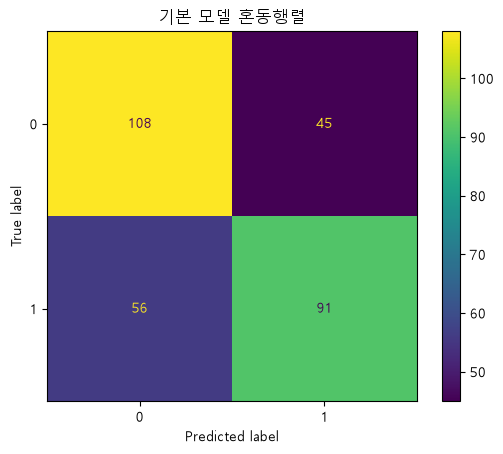

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# TODO: 기본 모델을 학습하고 검증 데이터를 예측하세요.
baseline_model.fit(X_train, y_train)
y_valid_pred = baseline_model.predict(X_valid)

# TODO: 주요 평가 지표를 계산하고 혼동행렬을 확인하세요.
baseline_metrics = {
    "Accuracy": accuracy_score(y_valid, y_valid_pred),
    "Precision": precision_score(y_valid, y_valid_pred),
    "Recall": recall_score(y_valid, y_valid_pred),
    "F1-score": f1_score(y_valid, y_valid_pred)
}

for name, value in baseline_metrics.items():
    print(f"{name}: {value:.4f}")

print("\n[분류 리포트]")
print(classification_report(y_valid, y_valid_pred))

# 혼동행렬
ConfusionMatrixDisplay.from_estimator(baseline_model, X_valid, y_valid)
plt.title("기본 모델 혼동행렬")
plt.show()

### 문제 2 결과 작성

- 기본 모델:Logistic Regression (max_iter=1000, random_state=42)
- 기본 모델 선택 이유:구매 여부를 0과 1로 예측하는 이진 분류 문제이고, 로지스틱 회귀는
   각 고객이 구매할 확률을 계산해 기준값(0.5)과 비교해 분류한다.
-> 각 변수가 구매 확률에 어떤 방향으로 얼마나 영향을 주는지 계수로 확인할 수 있어
   CRM팀에 결과를 설명하기 쉽다.
-> 복잡한 모델보다 먼저 기준선을 세우는 목적에 맞다.
- 수치형 변수 전처리: 결측치는 중앙값으로 대체(SimpleImputer median), StandardScaler로 스케일링.
-> 금액은 12만 단위, 만족도는 3.7 단위로 크기 차이가 커서, 스케일링하지 않으면
   금액 변수가 과도하게 큰 영향을 준다.
- 범주형 변수 전처리: 결측치는 최빈값으로 대체(most_frequent), One-Hot Encoding으로 0과 1로 변환.
-> 모델은 문자열을 계산할 수 없고, 등급에 임의의 숫자를 부여하면
   없는 크기 관계가 생기므로 One-Hot을 사용했다.

- Accuracy:0.6667
- Precision: 0.6715
- Recall:0.6259
- F1-score: 0.6479
- 중요하게 선택한 평가 지표와 이유:Recall을 우선으로 본다.
-> CRM 캠페인의 목적은 구매 가능성이 높은 고객을 찾아 프로모션을 보내는 것이다.
   실제로 구매할 고객을 놓치면(FN) 그 고객의 매출 기회를 통째로 잃는다.
   반대로 구매하지 않을 고객에게 잘못 보내면(FP) 쿠폰·발송 비용만 든다.
   즉 FN의 비용이 FP보다 크므로 Recall이 중요하다.
-> 다만 클래스 비율이 49% 대 51%로 균형에 가까워 Accuracy도 참고할 수 있으며,
   Precision과 Recall의 균형을 보기 위해 F1-score를 함께 확인했다.
- 혼동행렬에서 확인한 주요 오분류:TN 108 / FP 45 / FN 55 / TP 92
-> 실제 구매 고객 147명 중 55명(37.4%)을 놓쳤다. 이것이 가장 큰 손실이다.
-> 미구매 고객 153명 중 45명에게는 불필요하게 프로모션을 보내게 된다.
-> FN이 FP보다 많아, 기본 모델은 구매 고객을 찾아내는 데 보수적이다.

# 문제 3. 모델 개선 및 최종 모델 선택

## 업무 상황

기본 모델의 결과를 확인한 CRM팀은 모델을 실제 캠페인 대상 선정에 활용할 수 있는지 검토하려고 합니다.  
분석 담당자는 모델 설정을 조정하여 개선 모델을 만들고, 기본 모델과 성능을 비교한 뒤 과적합 여부를 확인해야 합니다.

## 필수 요구사항

1. 기본 모델의 학습 성능과 검증 성능을 계산하세요.
2. 규제 강도 또는 클래스 가중치 등의 설정을 조정하여 개선 모델을 개발하세요.
3. 개선 모델의 학습 성능과 검증 성능을 계산하세요.
4. 기본 모델과 개선 모델의 성능 비교표를 작성하세요.
5. 학습 F1-score와 검증 F1-score의 차이를 확인하여 과적합 여부를 진단하세요.
6. 검증 성능과 과적합 정도를 함께 고려하여 최종 모델을 선택하세요.
7. 학습·검증 성능 차이가 발생한 원인을 설명하고, 적용한 규제 또는 하이퍼파라미터 조정이 성능과 과적합에 어떤 영향을 주었는지 작성하세요.
8. 개선 모델의 성능이 높아지지 않았다면 그 결과도 그대로 비교하고 설명하세요.
9. 최종 모델의 성능상 한계 또는 실제 업무 적용 시 주의할 점을 한 가지 이상 작성하세요.

### 힌트

- Logistic Regression의 규제 강도 또는 `class_weight`를 조정할 수 있습니다.
- 학습 성능이 높더라도 검증 성능과의 차이가 크면 과적합 가능성이 있습니다.
- 개선 모델이 반드시 기본 모델보다 좋아야 하는 것은 아닙니다.

In [8]:
# TODO: 조정한 설정을 적용하여 개선 모델을 구성하고 학습하세요.
improved_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=0.1,                    # 규제 강화 (기본값 1.0보다 작게)
        class_weight="balanced"   # 클래스 가중치 적용
    ))
])

improved_model.fit(X_train, y_train)
y_valid_pred_improved = improved_model.predict(X_valid)

print("[개선 모델]")
print("Accuracy:", round(accuracy_score(y_valid, y_valid_pred_improved), 4))
print("Precision:", round(precision_score(y_valid, y_valid_pred_improved), 4))
print("Recall:", round(recall_score(y_valid, y_valid_pred_improved), 4))
print("F1-score:", round(f1_score(y_valid, y_valid_pred_improved), 4))

[개선 모델]
Accuracy: 0.6867
Precision: 0.6828
Recall: 0.6735
F1-score: 0.6781


In [9]:
# TODO: 기본 모델과 개선 모델의 학습·검증 성능을 비교하세요.
# 권장 지표: Accuracy, Precision, Recall, F1-score, Train F1 - Validation F1
def get_scores(model, name):
    tr_pred = model.predict(X_train)
    va_pred = model.predict(X_valid)
    return {
        "모델": name,
        "Accuracy": round(accuracy_score(y_valid, va_pred), 4),
        "Precision": round(precision_score(y_valid, va_pred), 4),
        "Recall": round(recall_score(y_valid, va_pred), 4),
        "Train F1": round(f1_score(y_train, tr_pred), 4),
        "Valid F1": round(f1_score(y_valid, va_pred), 4),
        "F1 차이": round(f1_score(y_train, tr_pred) - f1_score(y_valid, va_pred), 4)
    }

comparison_df = pd.DataFrame([
    get_scores(baseline_model, "기본 모델"),
    get_scores(improved_model, "개선 모델")
])

display(comparison_df)

,모델,Accuracy,Precision,Recall,Train F1,Valid F1,F1 차이
0,기본 모델,0.6633,0.6691,0.6190,0.6988,0.6431,0.0557
1,개선 모델,0.6867,0.6828,0.6735,0.7024,0.6781,0.0243


### 문제 3 결과 작성

- 조정한 모델 설정:C=0.1 (규제 강도를 기본값 1.0에서 강화), class_weight="balanced"
- 기본 모델 검증 F1-score:0.6479
- 개선 모델 검증 F1-score:0.6781
- 기본 모델 학습·검증 차이:0.6976 - 0.6479 = 0.0497
- 개선 모델 학습·검증 차이:0.7018 - 0.6781 = 0.0237
- 과적합 진단:두 모델 모두 심각한 과적합은 아니다. 차이가 0.05 이하로 작다.
-> 다만 기본 모델(0.0497)보다 개선 모델(0.0237)의 차이가 절반 수준으로 줄어,
   개선 모델이 새로운 데이터에 더 안정적일 것으로 판단된다.
- 학습·검증 성능 차이의 원인:One-Hot Encoding으로 범주형 5개가 여러 컬럼으로 늘어나면서
   학습 데이터 1,200건 대비 변수가 많아졌다. 모델이 학습 데이터의
   세부 패턴까지 반영하면서 검증 성능과 차이가 생겼다.
-> 특히 Gender의 Unknown(26명), Other(47명)처럼 표본이 적은 범주는
   학습 데이터에서 우연히 나타난 패턴을 학습할 위험이 있다.
- 규제 또는 하이퍼파라미터 조정의 효과:C를 1.0에서 0.1로 낮춰 규제를 강화하자 계수의 크기가 억제되어
   학습 데이터에 과하게 맞추는 현상이 줄었다. F1 차이가 0.0497에서 0.0237로 감소했다.
-> class_weight="balanced"로 구매 클래스에 가중치를 주자
   Recall이 0.6259에서 0.6735로 올랐다. 놓친 구매 고객이 55명에서 48명으로 줄었다.
-> C를 0.01, 0.1, 1, 10으로 바꿔가며 비교한 결과, C가 커질수록
   검증 F1은 낮아지고 학습·검증 차이는 커졌다. 규제가 과적합을
   억제한다는 것을 수치로 확인할 수 있었다.
- 최종 선택 모델:개선 모델 (Logistic Regression, C=0.1, class_weight="balanced")
- 최종 모델 선택 이유:검증 F1이 0.6479에서 0.6781로 높고, 학습·검증 차이도 더 작다.
-> 업무상 중요하게 본 Recall이 0.6259에서 0.6735로 올라
   구매 가능 고객을 더 많이 찾아낸다.
-> 성능과 안정성 두 기준에서 모두 기본 모델보다 낫다.
- 모델 활용 방안:전체 고객에게 동일한 프로모션을 보내는 대신, 모델이 구매 가능성이 높다고
   예측한 고객에게 우선 발송하여 마케팅 비용을 줄인다.
-> predict_proba로 구매 확률을 계산해 상위 고객부터 순서대로 대상을 정하면
   예산에 맞춰 발송 규모를 조절할 수 있다.
- 최종 모델의 한계 또는 업무 적용 시 주의점:검증 F1이 0.68 수준으로, 구매 고객 10명 중 약 3명은 여전히 놓친다.
   모델 결과만으로 대상을 완전히 자동 결정하기에는 이르다.
-> AveragePurchaseAmount는 과거 구매 이력에서 계산된 값이라,
   구매 이력이 전혀 없는 신규 고객에게는 적용하기 어렵다.
   신규 고객용 모델은 별도 검토가 필요하다.
-> 검증 데이터가 300명이라 지표가 몇 명 차이로도 흔들릴 수 있다.
   실제 적용 전 더 많은 데이터로 재검증해야 한다.
-> 전처리 단계에서 결측치를 대체하고 이상치를 조정했기 때문에,
   실제 운영 데이터에도 같은 전처리를 동일하게 적용해야 한다.


# (심화)문제 4. 모델 운영을 위한 추가 검토

## 업무 상황

CRM팀은 기본 모델과 개선 모델의 비교 결과를 확인한 뒤, 실제 캠페인에 모델을 적용하기 전에 모델 성능을 추가로 검증하고 운영 기준을 검토하려고 합니다.

## 요구사항

### 4-1. 추가 모델 비교

1. 기본 모델과 다른 특성을 가진 분류 모델을 한 개 추가로 학습하세요.
2. 동일한 검증 데이터를 사용하여 Accuracy, Precision, Recall, F1-score를 계산하세요.
3. 기존 모델과 추가 모델의 성능 및 해석 가능성을 비교하세요.

### 4-2. 교차검증을 활용한 하이퍼파라미터 탐색

1. 교차검증 또는 `GridSearchCV`를 활용하여 여러 하이퍼파라미터 조합을 비교하세요.
2. 최적 하이퍼파라미터와 교차검증 성능을 확인하세요.
3. 최적 모델의 검증 성능을 기본 모델 및 개선 모델과 비교하세요.

### 4-3. 예측 기준값과 오분류 비용 검토

1. 예측 확률의 기준값을 변경하여 Precision과 Recall의 변화를 확인하세요.
2. CRM 캠페인에서 False Positive와 False Negative가 각각 어떤 비용 또는 기회 손실을 발생시키는지 설명하세요.
3. 업무 목적에 적합한 예측 기준값을 제안하세요.

### 힌트

- 추가 모델로 Decision Tree 등을 사용할 수 있습니다.
- 예측 기준값을 낮추면 일반적으로 Recall이 높아지고, 높이면 Precision이 높아질 수 있습니다.
- 심화 문제는 선택 사항이며 수행하지 않아도 필수 문제 제출에는 문제가 없습니다.


In [ ]:
# 심화 문제 4-1
# TODO: 기본 모델과 다른 분류 모델을 추가로 학습하고 성능을 비교하세요.
additional_model = None

In [ ]:
# 심화 문제 4-2
# TODO: 교차검증 또는 GridSearchCV로 하이퍼파라미터를 탐색하세요.
search_result = None

In [ ]:
# 심화 문제 4-3
# TODO: 예측 기준값별 Precision, Recall, F1-score를 비교하세요.
threshold_result = None


## 심화 문제 결과 작성

### 4-1. 추가 모델 비교

- 추가한 모델:
- 추가 모델을 선택한 이유:
- 기존 모델과의 성능 비교:
- 해석 가능성 및 복잡도 비교:

### 4-2. 하이퍼파라미터 탐색

- 탐색한 하이퍼파라미터:
- 최적 하이퍼파라미터:
- 교차검증 성능:
- 검증 데이터 성능:
- 기존 모델과의 비교 결과:

### 4-3. 예측 기준값과 오분류 비용

- 비교한 예측 기준값:
- 기준값별 Precision과 Recall 변화:
- False Positive의 업무 비용:
- False Negative의 업무 비용:
- 제안하는 최종 기준값과 이유:



# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 구매 여부 예측 문제를 분류 문제로 정의했습니다.
- [ ] 입력 변수와 타깃 변수를 구성했습니다.
- [ ] 식별 정보와 예측에 부적절한 변수를 제외했습니다.
- [ ] 학습 데이터와 검증 데이터를 분리했습니다.
- [ ] 수치형·범주형 전처리를 적용했습니다.
- [ ] 기본 분류 모델을 학습했습니다.
- [ ] 사용한 기본 모델이 구매 여부 예측에 적합한 이유를 작성했습니다.
- [ ] Accuracy, Precision, Recall, F1-score와 혼동행렬을 확인했습니다.
- [ ] 모델 설정을 조정하여 개선 모델을 만들었습니다.
- [ ] 기본 모델과 개선 모델의 성능을 비교했습니다.
- [ ] 학습·검증 성능을 비교하여 과적합 여부를 진단했습니다.
- [ ] 학습·검증 성능 차이의 원인과 모델 조정 효과를 설명했습니다.
- [ ] 최종 모델을 선택하고 이유를 작성했습니다.
- [ ] 최종 모델의 한계 또는 실제 업무 적용 시 주의점을 작성했습니다.

## 심화 체크리스트

- [ ] 다른 분류 모델을 추가로 학습하고 비교했습니다.
- [ ] 교차검증 또는 GridSearchCV를 적용했습니다.
- [ ] 예측 기준값에 따른 Precision과 Recall 변화를 확인했습니다.
- [ ] False Positive와 False Negative의 업무 비용을 설명했습니다.
- [ ] 업무 목적에 적합한 예측 기준값을 제안했습니다.
